# U4 — Additivity / Interaction (subset budget-dependence gate)

단일층 회복이 subset으로 가산되는가?  `I_ij(t) = R({i,j};t) − R(i;t) − R(j;t)`.

- `< 0` subadditive(redundancy) → U5 **greedy** 필요 (naive top-k 과대예측)
- `≈ 0` 가법 → top-k OK
- `> 0` synergy

엔진 `run_u4_additivity` (multi-t 공짜, seed-matched). 산출 → Drive `outputs/U4/`.

In [1]:
# --- Colab 셋업 ---
import os
REPO = '/content/26_Capstone'
if not os.path.isdir(REPO):
    !git clone -q https://github.com/u-nsiq/26_Capstone.git {REPO}
else:
    !git -C {REPO} pull -q
os.chdir(REPO)
!pip install -q -r requirements.txt
import torch; print('torch', torch.__version__, '| cuda', torch.cuda.is_available())

torch 2.11.0+cu128 | cuda True


In [2]:
# --- 엔진 + Drive + 경로 + FP baseline (S1.5와 동일 패턴) ---
from qat_engine import *
import numpy as np, matplotlib.pyplot as plt, json, itertools, math

try:
    from google.colab import drive; drive.mount('/content/drive')
    ART = '/content/drive/MyDrive/26_Capstone'
except Exception:
    ART = './_local_art'
for sub in ['checkpoints', 'outputs/U4', 'figures']:
    os.makedirs(f'{ART}/{sub}', exist_ok=True)
DATA_ROOT = f'{ART}/data'
CKPT   = f'{ART}/checkpoints/resnet18_cifar100_fp32.pt'   # S1.2/S1.5 캐시 (train_baseline resume)
OUTDIR = f'{ART}/outputs/U4'
N_BITS = 3                                                 # W3 = main recoverable (U0)

train_loader, val_loader, calib_loader = get_loaders('cifar100', batch=128, calib_size=1024, data_root=DATA_ROOT)
fp_model = load_model('resnet18', 'cifar100')
fp_model, fp_acc = train_baseline(fp_model, train_loader, val_loader, ckpt_path=CKPT, resume=True)
fp_model.eval()
print('device', DEVICE, '| fp_acc', round(fp_acc, 2), '| out', OUTDIR)

Mounted at /content/drive
[baseline] 캐시 로드 /content/drive/MyDrive/26_Capstone/checkpoints/resnet18_cifar100_fp32.pt → top1 76.84
device cuda | fp_acc 76.84 | out /content/drive/MyDrive/26_Capstone/outputs/U4


In [3]:
# === PTQ + proxy → normHd2 상위 N층 ===
TOPN = 6                                  # 시간 되면 8 (top-8 = 28쌍)
ptq_model = make_ptq_model(fp_model, N_BITS, DEVICE)
scores = proxy_scores(ptq_model, fp_model, N_BITS, calib_loader)
top_layers = sorted(scores, key=lambda n: scores[n]['normHd2'], reverse=True)[:TOPN]
print('normHd2 상위:')
for n in top_layers:
    nh, dh = scores[n]['normHd2'], scores[n]['dtHd']
    print(f'  {n:<22} normHd2={nh:.3f}  dtHd={dh:.3f}')

normHd2 상위:
  layer1.0.conv1         normHd2=19.636  dtHd=0.451
  layer1.0.conv2         normHd2=11.948  dtHd=0.287
  conv1                  normHd2=7.981  dtHd=0.563
  layer1.1.conv1         normHd2=4.398  dtHd=0.128
  layer2.0.conv1         normHd2=3.241  dtHd=0.129
  layer3.0.conv1         normHd2=2.157  dtHd=0.176


In [4]:
# === U4: 단일+쌍 회복 → I_ij(t)  (multi-t 공짜, seed-matched) ===
SEEDS = (0, 1, 2, 3, 4)                    # seed 3→5 (유의성, 리뷰)
res = run_u4_additivity(fp_model, N_BITS, top_layers, train_loader, val_loader,
                        steps=800, eval_at=(30, 100, 300, 800), seeds=SEEDS, device=DEVICE)  # +800 anchor
print('L_PTQ =', round(res['L_PTQ'], 4), '| seeds =', res['n_seeds'], '| pairs =', len(res['I']))

L_PTQ = 1.5512 | seeds = 5 | pairs = 15


In [5]:
# === Drive 저장 ===
path = f'{OUTDIR}/u4_additivity_w{N_BITS}.json'
with open(path, 'w') as f:
    json.dump(res, f, indent=2)
print('saved →', path)

saved → /content/drive/MyDrive/26_Capstone/outputs/U4/u4_additivity_w3.json


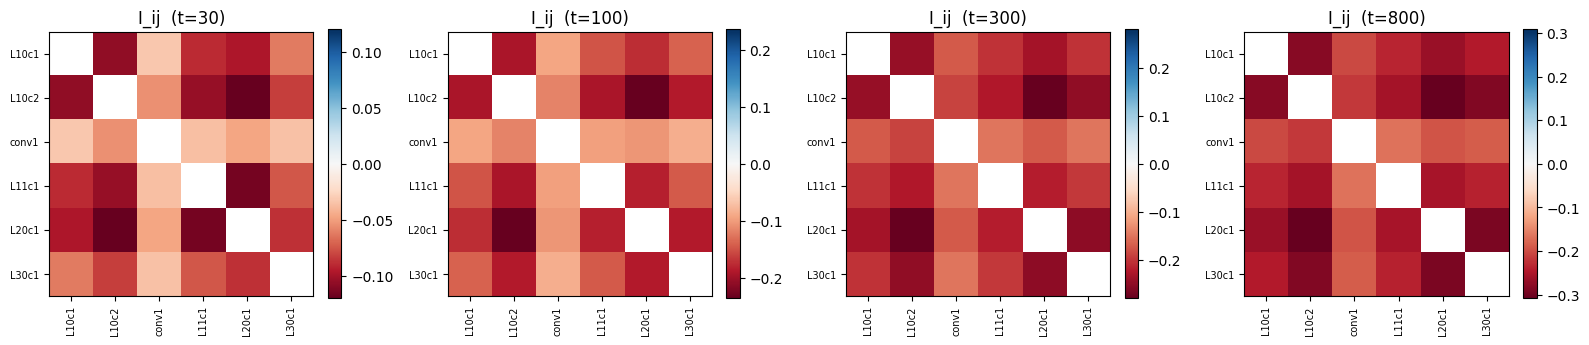

부호 요약 (gate, +유의 neg = seed-CI 상단<0):
  t=30   15/15 neg | 15/15 *유의*neg | median=-0.0833
  t=100  15/15 neg | 15/15 *유의*neg | median=-0.1482
  t=300  15/15 neg | 15/15 *유의*neg | median=-0.2024
  t=800  15/15 neg | 15/15 *유의*neg | median=-0.2431


In [6]:
# === I_ij(t) 히트맵 + 부호 요약 (gate, +유의성) ===
layers, T = res['layers'], res['t_evals']
short = [n.replace('layer', 'L').replace('.conv', 'c').replace('.', '') for n in layers]
fig, axes = plt.subplots(1, len(T), figsize=(4.0 * len(T), 4)); axes = np.atleast_1d(axes)
for ax, t in zip(axes, T):
    M = np.full((len(layers), len(layers)), np.nan)
    for a, b in itertools.combinations(range(len(layers)), 2):
        M[a, b] = M[b, a] = res['I'][f'{layers[a]}|{layers[b]}'][t]
    vmax = np.nanmax(np.abs(M))
    im = ax.imshow(M, cmap='RdBu', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(layers))); ax.set_xticklabels(short, rotation=90, fontsize=7)
    ax.set_yticks(range(len(layers))); ax.set_yticklabels(short, fontsize=7)
    ax.set_title(f'I_ij  (t={t})'); fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.savefig(f'{OUTDIR}/u4_heatmap_w{N_BITS}.png', dpi=120); plt.show()

# 유의성 게이트: seed-CI 상단(mean + 2·std/√n) < 0 이면 *유의하게* subadditive (리뷰)
n = res['n_seeds']
print('부호 요약 (gate, +유의 neg = seed-CI 상단<0):')
for t in T:
    items = [(res['I'][k][t], res['I_std'][k][t]) for k in res['I']]
    neg = sum(m < 0 for m, s in items)
    signeg = sum((m + 2 * s / math.sqrt(n)) < 0 for m, s in items)
    med = np.median([m for m, _ in items])
    print(f'  t={t:<4} {neg}/{len(items)} neg | {signeg}/{len(items)} *유의*neg | median={med:+.4f}')

In [7]:
# === redundancy 경향 + 가산성의 예산의존 ===
t0 = res['t_evals'][0]                     # 가장 짧은 t (short-budget)
pairs = list(itertools.combinations(layers, 2))
nh = [scores[i]['normHd2'] * scores[j]['normHd2'] for i, j in pairs]
Ival = [res['I'][f'{i}|{j}'][t0] for i, j in pairs]
print(f'corr(normHd2_i·normHd2_j , I_ij) @t={t0}: spearman={spearman(nh, Ival):+.3f}  (음수강=상위층끼리 중복)')

stage = lambda n: n.split('.')[0]
same = [res['I'][f'{i}|{j}'][t0] for i, j in pairs if stage(i) == stage(j)]
diff = [res['I'][f'{i}|{j}'][t0] for i, j in pairs if stage(i) != stage(j)]
print(f'same-stage median I={np.median(same):+.4f} (n={len(same)})  |  diff-stage median I={np.median(diff):+.4f} (n={len(diff)})')

print('mean|I| vs t (가산성의 예산의존):')
for t in res['t_evals']:
    mI = np.mean([abs(res['I'][k][t]) for k in res['I']])
    print(f'  t={t:<4} mean|I|={mI:.4f}')

corr(normHd2_i·normHd2_j , I_ij) @t=30: spearman=-0.025  (음수강=상위층끼리 중복)
same-stage median I=-0.1044 (n=3)  |  diff-stage median I=-0.0682 (n=12)
mean|I| vs t (가산성의 예산의존):
  t=30   mean|I|=0.0764
  t=100  mean|I|=0.1521
  t=300  mean|I|=0.2090
  t=800  mean|I|=0.2414


## Gate 판정 → U5

- **대부분 t에서 I_ij < 0 우세** → **subadditive(redundancy) 확정** → U5는 **greedy / redundancy-aware** (naive top-k는 subset 회복 *과대예측*)
- I_ij ≈ 0 → 단순 top-k 정당화
- I_ij > 0 → synergy-aware

추가로 보는 것:
- **normHd2 상위끼리 더 음수** → "좋은 층끼리 같은 오차 고침" (redundancy 메커니즘)
- **같은 stage 더 음수** → stage-diverse 선택(U5 후보 A)의 근거
- **mean|I|가 t 따라 변함** → 가산성도 *예산의존* (U5 subset-level budget-dependence 예고)